/var/folders/rq/kntc9k917_g4nycng5t1p6wr0000gn/T/ipykernel_33114/3333746679.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_long["Date"] = pd.to_datetime(df_long["Year"].astype(str) + "-" + df_long["Month"])


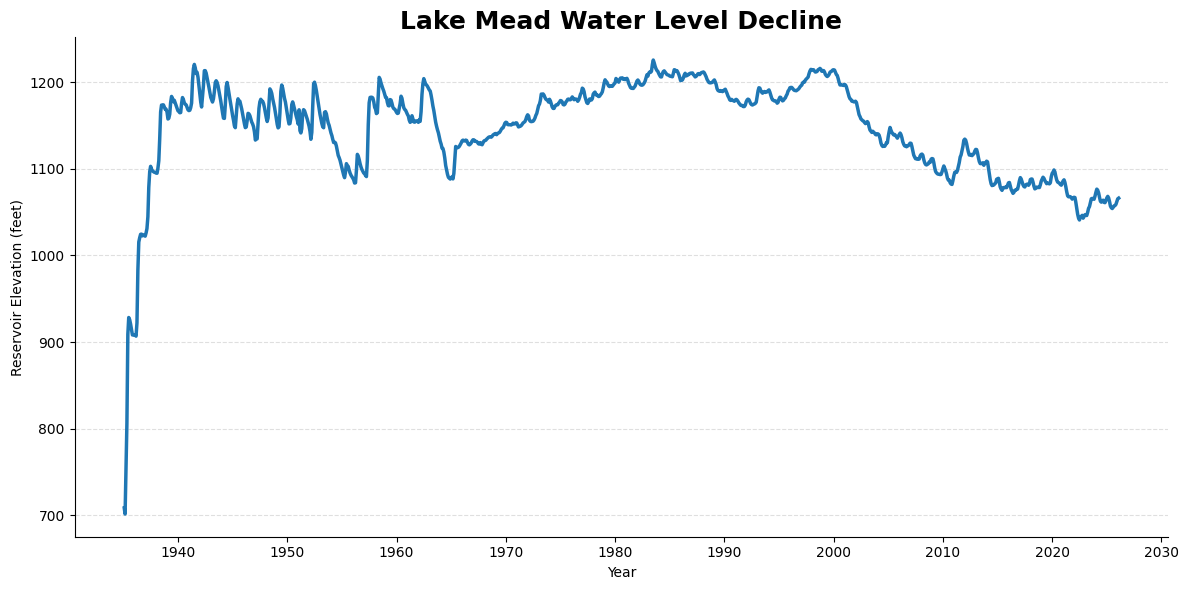

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("LAKE MEAD data.csv")

df = df.replace('---', None)

df_long = df.melt(
    id_vars="Year",
    var_name="Month",
    value_name="Elevation"
)

df_long["Elevation"] = pd.to_numeric(df_long["Elevation"])

df_long["Date"] = pd.to_datetime(df_long["Year"].astype(str) + "-" + df_long["Month"])

df_long = df_long.sort_values("Date")

plt.figure(figsize=(12,6))

plt.plot(
    df_long["Date"],
    df_long["Elevation"],
    linewidth=2.5
)

plt.title("Lake Mead Water Level Decline", fontsize=18, weight='bold')
plt.ylabel("Reservoir Elevation (feet)")
plt.xlabel("Year")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig("lake_mead_decline.svg")

plt.show()

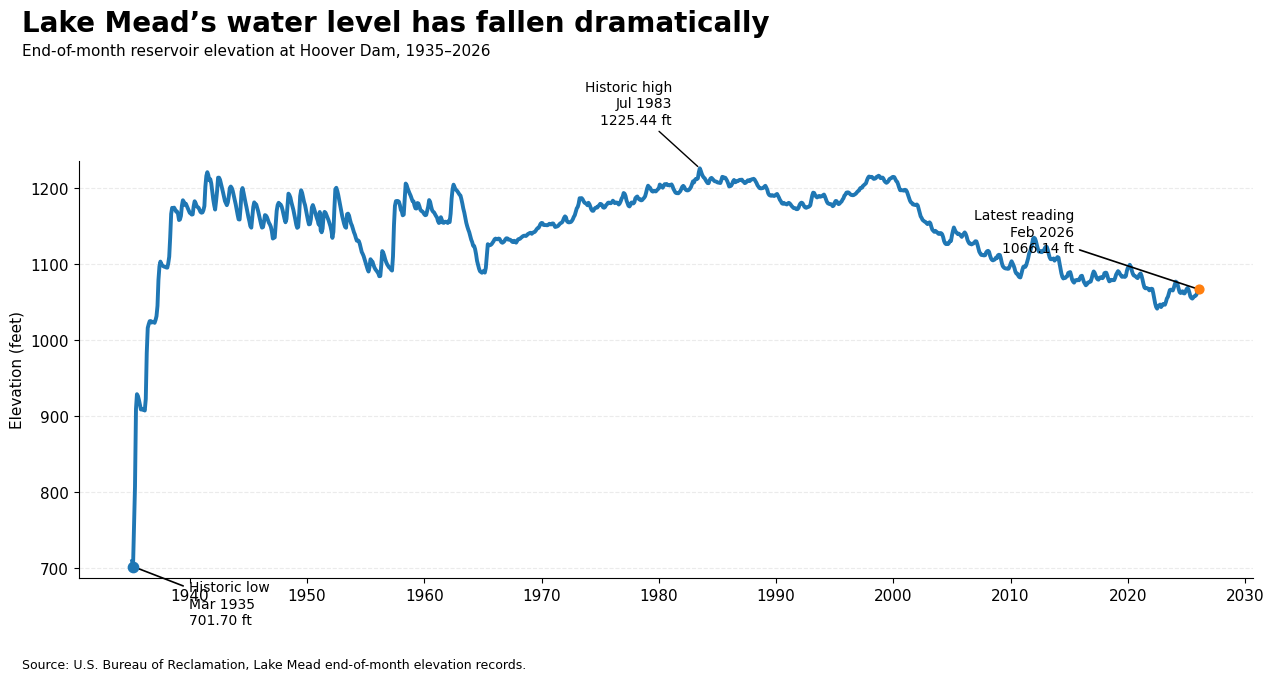

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv("LAKE MEAD data.csv")

df = df.replace('---', None)

df_long = df.melt(
    id_vars="Year",
    var_name="Month",
    value_name="Elevation"
)

df_long["Elevation"] = pd.to_numeric(df_long["Elevation"], errors="coerce")

df_long["Date"] = pd.to_datetime(
    df_long["Year"].astype(str) + "-" + df_long["Month"],
    format="%Y-%b",
    errors="coerce"
)

df_long = df_long.dropna(subset=["Date", "Elevation"]).sort_values("Date")

low_2022 = df_long.loc[df_long["Elevation"].idxmin()]
latest = df_long.iloc[-1]

high_point = df_long.loc[df_long["Elevation"].idxmax()]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    df_long["Date"],
    df_long["Elevation"],
    linewidth=2.8
)

ax.scatter(
    low_2022["Date"],
    low_2022["Elevation"],
    s=55,
    zorder=5
)

ax.scatter(
    latest["Date"],
    latest["Elevation"],
    s=40,
    zorder=5
)

fig.text(
    0.08, 0.95,
    "Lake Mead’s water level has fallen dramatically",
    fontsize=20,
    fontweight="bold",
    ha="left"
)

fig.text(
    0.08, 0.915,
    "End-of-month reservoir elevation at Hoover Dam, 1935–2026",
    fontsize=11,
    ha="left"
)

ax.annotate(
    f"Historic low\n{low_2022['Date'].strftime('%b %Y')}\n{low_2022['Elevation']:.2f} ft",
    xy=(low_2022["Date"], low_2022["Elevation"]),
    xytext=(40, -10),
    textcoords="offset points",
    fontsize=10,
    ha="left",
    va="top",
    arrowprops=dict(arrowstyle="-", lw=1.2)
)

ax.annotate(
    f"Latest reading\n{latest['Date'].strftime('%b %Y')}\n{latest['Elevation']:.2f} ft",
    xy=(latest["Date"], latest["Elevation"]),
    xytext=(-90, 25),
    textcoords="offset points",
    fontsize=10,
    ha="right",
    va="bottom",
    arrowprops=dict(arrowstyle="-", lw=1.2)
)

ax.annotate(
    f"Historic high\n{high_point['Date'].strftime('%b %Y')}\n{high_point['Elevation']:.2f} ft",
    xy=(high_point["Date"], high_point["Elevation"]),
    xytext=(-20, 30),
    textcoords="offset points",
    fontsize=10,
    ha="right",
    va="bottom",
    arrowprops=dict(arrowstyle="-", lw=1.0)
)

ax.set_ylabel("Elevation (feet)", fontsize=11)
ax.set_xlabel("")

ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ymin = df_long["Elevation"].min() - 15
ymax = df_long["Elevation"].max() + 10
ax.set_ylim(ymin, ymax)

fig.text(
    0.08, 0.04,
    "Source: U.S. Bureau of Reclamation, Lake Mead end-of-month elevation records.",
    fontsize=9,
    ha="left"
)

plt.tight_layout(rect=[0.06, 0.08, 0.98, 0.9])

plt.savefig("lake_mead_decline_editorial.svg", format="svg", bbox_inches="tight")
plt.savefig("lake_mead_decline_editorial.png", dpi=300, bbox_inches="tight")

plt.show()

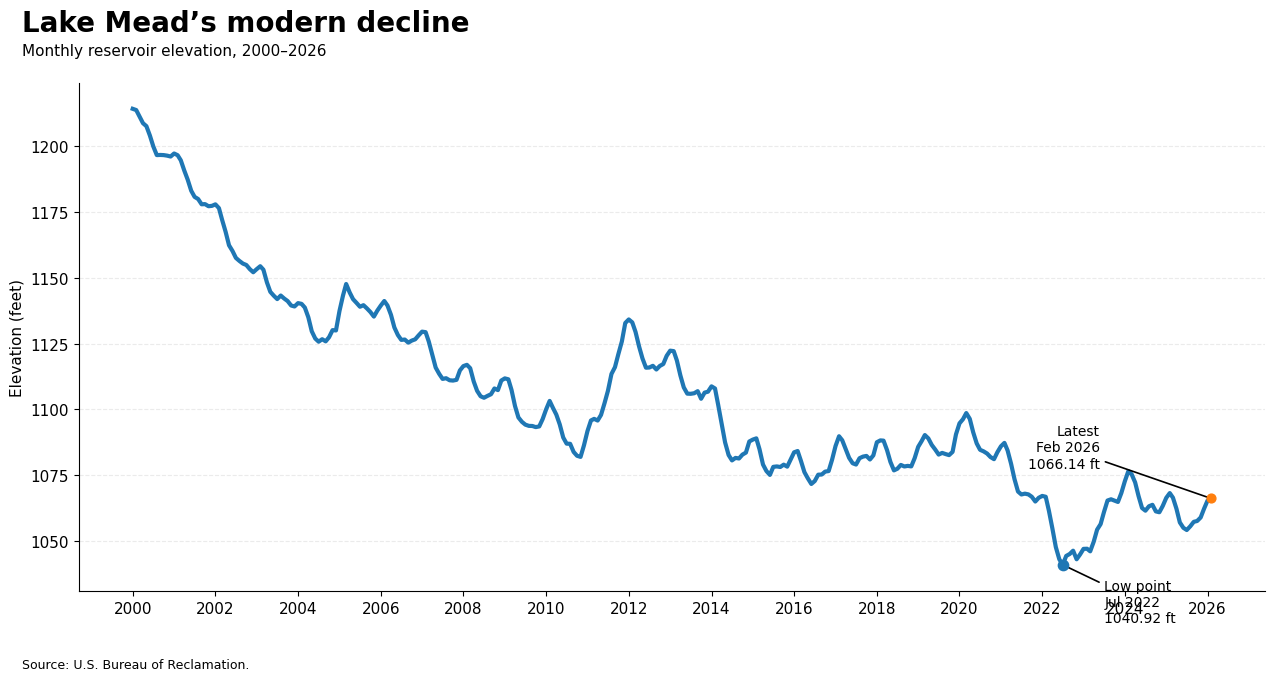

In [3]:
recent = df_long[df_long["Date"] >= "2000-01-01"].copy()

low_recent = recent.loc[recent["Elevation"].idxmin()]
latest_recent = recent.iloc[-1]

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    recent["Date"],
    recent["Elevation"],
    linewidth=3
)

ax.scatter(low_recent["Date"], low_recent["Elevation"], s=55, zorder=5)
ax.scatter(latest_recent["Date"], latest_recent["Elevation"], s=40, zorder=5)

fig.text(
    0.08, 0.95,
    "Lake Mead’s modern decline",
    fontsize=20,
    fontweight="bold",
    ha="left"
)

fig.text(
    0.08, 0.915,
    "Monthly reservoir elevation, 2000–2026",
    fontsize=11,
    ha="left"
)

ax.annotate(
    f"Low point\n{low_recent['Date'].strftime('%b %Y')}\n{low_recent['Elevation']:.2f} ft",
    xy=(low_recent["Date"], low_recent["Elevation"]),
    xytext=(30, -10),
    textcoords="offset points",
    fontsize=10,
    ha="left",
    va="top",
    arrowprops=dict(arrowstyle="-", lw=1.2)
)

ax.annotate(
    f"Latest\n{latest_recent['Date'].strftime('%b %Y')}\n{latest_recent['Elevation']:.2f} ft",
    xy=(latest_recent["Date"], latest_recent["Elevation"]),
    xytext=(-80, 20),
    textcoords="offset points",
    fontsize=10,
    ha="right",
    va="bottom",
    arrowprops=dict(arrowstyle="-", lw=1.2)
)

ax.set_ylabel("Elevation (feet)")
ax.set_xlabel("")

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_ylim(recent["Elevation"].min() - 10, recent["Elevation"].max() + 10)

fig.text(
    0.08, 0.04,
    "Source: U.S. Bureau of Reclamation.",
    fontsize=9,
    ha="left"
)

plt.tight_layout(rect=[0.06, 0.08, 0.98, 0.9])

plt.savefig("lake_mead_decline_2000_onward.svg", format="svg", bbox_inches="tight")
plt.savefig("lake_mead_decline_2000_onward.png", dpi=300, bbox_inches="tight")

plt.show()